# Load SBI Checkpoint

Minimal example for restoring a trained `train_script_sbi.py` checkpoint and running the flow.

In [1]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt


In [2]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/updated5_b3s_2_4_6_128")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
model.eval()

In [3]:
total_params = jax.tree_util.tree_reduce(lambda x, y: x + y.size, params, initializer=0)
print(f"Total parameters: {total_params:,}")

Total parameters: 6,816,361


In [4]:
total_params_encoder = jax.tree_util.tree_reduce(lambda x, y: x + y.size, params["encoder"], initializer=0)
print(f"Total encoder parameters: {total_params_encoder:,}")

Total encoder parameters: 340,894


In [5]:
list(params.keys())

['encoder', 'inference_decoder', 'model_decoder', 'tokenizer']

In [6]:
total_params_encoder = jax.tree_util.tree_reduce(lambda x, y: x + y.size, params["inference_decoder"], initializer=0)
print(f"Total encoder parameters: {total_params_encoder:,}")

Total encoder parameters: 4,547,648


In [7]:
total_params_encoder = jax.tree_util.tree_reduce(lambda x, y: x + y.size, params["model_decoder"], initializer=0)
print(f"Total encoder parameters: {total_params_encoder:,}")

Total encoder parameters: 1,913,921


In [8]:
total_params_encoder = jax.tree_util.tree_reduce(lambda x, y: x + y.size, params["tokenizer"], initializer=0)
print(f"Total encoder parameters: {total_params_encoder:,}")

Total encoder parameters: 13,898


In [23]:
from dmri.simulators.models import Ball3StickSharedDiffusivity
from dmri.simulators import acquisition_scheme
from dmri.simulators.acquisition_scheme import random_hcp_acquisition,random_hcp_large_acquisition
import jax
import jax.numpy as jnp
import numpy as np
from functools import partial
sim_type = Ball3StickSharedDiffusivity

@jax.jit
def sample_fn(rng, acq, x_o, num_samples=50):
    keys = jax.random.split(rng, num_samples)
    return jax.vmap(partial(model.sample_theta, num_steps=128, last_euler_step=True, t_min=1e-3), in_axes=(0, None, None, None))(keys, acq, x_o, jnp.ones((5,), dtype=bool))

# Metric only
@jax.jit
def log_prob_fn(thetas, acq, x_o):
    return jax.vmap(partial(model.log_prob_theta, num_steps=256), in_axes=(0, None, None, None))(thetas, acq, x_o, jnp.ones((5,), dtype=bool))

In [24]:
acq = random_hcp_acquisition(jax.random.key(1))

theta = jax.random.normal(jax.random.key(40), (sim_type.theta_dim,))
x_o = sim_type.from_theta(theta).signal(acq, jax.random.key(3))

In [25]:
model.map_model_mask(jax.random.key(0), acq=acq, x=x_o, mask_prior=0.1)

Array([ True,  True, False, False,  True], dtype=bool)

In [26]:
theta_samples = sample_fn(jax.random.key(4), acq, x_o).block_until_ready()

In [27]:
log_q = log_prob_fn(theta_samples, acq, x_o).block_until_ready()
rmse = jnp.sqrt(jnp.mean((theta_samples.mean(axis=0) - theta) ** 2))

rmse, theta_samples.shape, log_q.shape

(Array(0.5498556, dtype=float32), (50, 11), (50,))

In [28]:
from functools import partial
@partial(jax.vmap, in_axes=(0, None, None))
def posterior_pdf(theta, acq, x_o):
    simulator = sim_type.from_theta(theta)
    return simulator.log_likelihood(acq, x_o)

In [29]:
log_p = posterior_pdf(theta_samples, acq, x_o)

In [30]:
batched_sample_fn = jax.jit(jax.vmap(sample_fn, in_axes=(0, 0, 0)))
batched_log_prob_fn = jax.jit(lambda x,y,z: jax.lax.map(lambda x: log_prob_fn(x[0], x[1], x[2]), (x,y,z), batch_size=512))

In [31]:
def ess(log_p, log_q):
    logw = log_p - log_q
    finite = jnp.isfinite(logw)
    lw = jnp.where(finite, logw, -jnp.inf)
    lw_max = jnp.max(lw)
    shifted = lw - lw_max
    w = jnp.where(finite, jnp.exp(shifted), 0.0)
    sum_w = jnp.sum(w)
    sum_w2 = jnp.sum(w * w)
    ess = (sum_w * sum_w) / jnp.maximum(sum_w2, 1e-30)
    return ess
@jax.jit
def rmse_fn(theta_samples, x_o, acq, rng):
    @partial(jax.vmap, in_axes=(0, None,0))
    def forward_model(theta, acq, rng):
        simulator = sim_type.from_theta(theta)
        return simulator.signal(acq, rng)
    rng = jax.random.split(rng, theta_samples.shape[0])
    x_o_pred = forward_model(theta_samples, acq, rng)
    rmse_val = jnp.sqrt(jnp.mean((x_o_pred - x_o) ** 2, axis=-1))
    return rmse_val

def make_keys(num_trials, offset):
    trial_ids = jnp.arange(num_trials)
    return jax.vmap(lambda i: jax.random.key(i + offset))(trial_ids)

@jax.jit
def simulate_signal(theta, acq, rng):
    simulator = sim_type.from_theta(theta)
    return simulator.signal(acq, rng)



batched_posterior_pdf = jax.jit(jax.vmap(posterior_pdf, in_axes=(0, 0, 0)))
batched_ess = jax.jit(jax.vmap(ess, in_axes=(0, 0)))
batched_rmse_fn = jax.jit(jax.vmap(rmse_fn, in_axes=(0, 0, 0, 0)))

def simulate_dataset(acquisition_fn, num_trials=100):
    acq_keys = make_keys(num_trials, 0)
    theta_keys = make_keys(num_trials, 1)
    signal_keys = make_keys(num_trials, 2)
    sample_keys = make_keys(num_trials, 3)
    rmse_keys = make_keys(num_trials, 4)

    acqs = jax.vmap(acquisition_fn)(acq_keys)
    thetas = jax.vmap(lambda key: jax.random.normal(key, (sim_type.theta_dim,)))(theta_keys)
    x_o = jax.vmap(simulate_signal)(thetas, acqs, signal_keys)
    return acqs, thetas, x_o, sample_keys, rmse_keys

def evaluate_regime_vmap(acquisition_fn, num_trials=100):
    acqs, thetas, x_o, sample_keys, rmse_keys = simulate_dataset(acquisition_fn, num_trials=num_trials)
    theta_samples = batched_sample_fn(sample_keys, acqs, x_o).block_until_ready()
    log_p = batched_posterior_pdf(theta_samples, acqs, x_o)
    log_q = batched_log_prob_fn(theta_samples, acqs, x_o)
    ess_vals = batched_ess(log_p, log_q) / theta_samples.shape[1]
    rmse_vals = batched_rmse_fn(theta_samples, x_o, acqs, rmse_keys)
    return thetas, theta_samples, ess_vals, rmse_vals

In [32]:
ess

<function __main__.ess(log_p, log_q)>

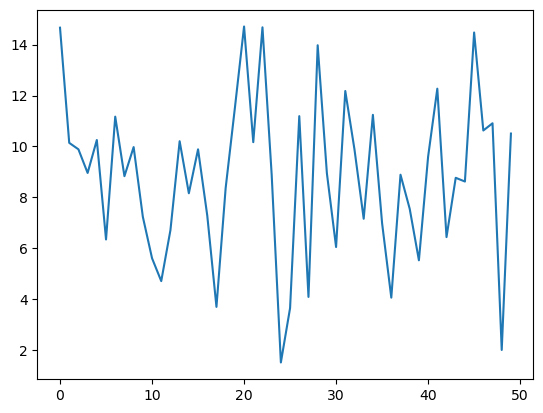

In [33]:
plt.plot(log_p)

In [34]:
thetas, theta_samples, ess_list, rmse_list = evaluate_regime_vmap(random_hcp_acquisition, num_trials=512)

In [35]:
import numpy as np
ess_list = np.array(ess_list)
rmse_list = np.array(rmse_list)

mean_ess = np.mean(ess_list)
median_ess = np.median(ess_list)
q10 = np.quantile(ess_list, 0.1)
q90 = np.quantile(ess_list, 0.9)
mean_rmse = np.mean(rmse_list)
median_rmse = np.median(rmse_list)
q10_rmse = np.quantile(rmse_list, 0.1)
q90_rmse = np.quantile(rmse_list, 0.9)

In [36]:
mean_ess, median_ess, q10, q90, mean_rmse, median_rmse, q10_rmse, q90_rmse

(np.float32(0.09517704),
 np.float32(0.081120454),
 np.float32(0.02742109),
 np.float32(0.17899136),
 np.float32(0.060425915),
 np.float32(0.03603355),
 np.float32(0.020019405),
 np.float32(0.13155599))

In [24]:
thetas_long, theta_samples_long, ess_list_long, rmse_list_long = evaluate_regime_vmap(random_hcp_large_acquisition, num_trials=1000)

W0329 11:10:24.632150 3200893 hlo_rematerialization.cc:3204] Can't reduce memory use below 56.41GiB (60567334510 bytes) by rematerialization; only reduced to 72.88GiB (78249197208 bytes), down from 82.43GiB (88513456457 bytes) originally
W0329 11:10:55.427457 3200893 bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 75.90GiB (rounded to 81500657920)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0329 11:10:55.428280 3200893 bfc_allocator.cc:512] *___________________________________________________________________________________________________
E0329 11:10:55.428313 3200893 pjrt_stream_executor_client.cc:2085] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 75.90GiB. [tf-allocator-allocation-error='']


JaxRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 75.90GiB.

In [ ]:
ess_list_long = np.array(ess_list_long)
rmse_list_long = np.array(rmse_list_long)

In [ ]:
median_ess = np.median(ess_list_long)
q10_long = np.quantile(ess_list_long, 0.1)
q90_long = np.quantile(ess_list_long, 0.9)
mean_rmse_long = np.mean(rmse_list_long)
q10_rmse_long = np.quantile(rmse_list_long, 0.1)
q90_rmse_long = np.quantile(rmse_list_long, 0.9)

In [ ]:
np.mean(ess_list_long)

In [ ]:
median_ess, q10_long, q90_long, mean_rmse_long, q10_rmse_long, q90_rmse_long